## Imports das Bibliotecas

In [271]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Analise dos dados

In [272]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11432 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11432 non-null  int64 
 3   keywords               5072 non-null   object
 4   nome                   11432 non-null  object
 5   sexo                   11432 non-null  object
 6   nascimento             11432 non-null  object
 7   local_nascimento       11432 non-null  object
 8   escolaridade           11170 non-null  object
 9   uris.uriPartido        11432 non-null  object
 10  ementa_principal       11432 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           11432 non-null  object
 15  sigla_partido          1

In [273]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [274]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [275]:
df["sigla_partido"].unique()

array(['PR', 'PSOL', 'PSB', 'MDB', 'DEM', 'PT', 'SOLIDARIEDADE', 'PMDB',
       'PP**', 'PV', 'PL', 'PSL', 'PPS', 'S.PART.', 'SDD', 'AVANTE',
       'PTB', 'PDT', 'PCdoB', 'PSDB', 'PHS', 'REPUBLICANOS', 'UNIÃO',
       'PP', 'PRTB', 'PSD', 'PROS', 'PSC', 'PMN', 'PRP', 'PATRI', 'PODE',
       'PRB', 'CIDADANIA', 'PRD', 'NOVO', 'PATRIOTA', 'REDE'],
      dtype=object)

In [276]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

C:\Users\alexa\AppData\Local\Temp\ipykernel_27076\1803048690.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["

In [277]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

C:\Users\alexa\AppData\Local\Temp\ipykernel_27076\188054785.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["cor"].loc[(df["cor"] == "AMARELA") | (
C:\Users\alexa\AppData\Local\Temp\ipykernel_27076\188054785.py:4: SettingWithCopyWarni

In [278]:
partido = df["sigla_partido"].value_counts().reset_index()
partido["sigla_partido"].unique()
partido

,sigla_partido,count
0,PL,1202
1,UNIÃO,729
2,PT,458
3,REPUBLICANOS,398
4,PP,386
5,PSOL,316
6,NOVO,309
7,PSD,270
8,MDB,253
9,PDT,183


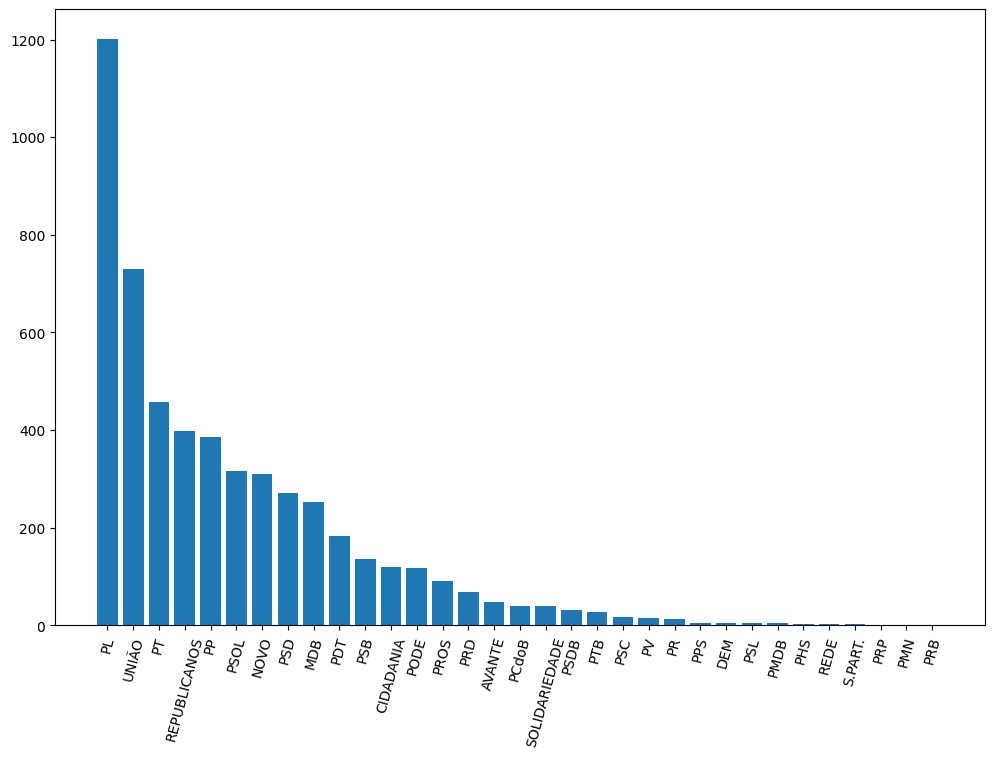

In [279]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(partido["sigla_partido"], height=partido["count"])
plt.xticks(rotation=75)
plt.show()

In [280]:
df["ementa"].dropna().count()

5292

## Bag Of Words

In [281]:
# nltk.download('stopwords')

In [282]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [283]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab

array(['00', '000', '001', ..., 'único', 'útero', 'útil'], dtype=object)

## WORD CLOUD

In [284]:
le = LabelEncoder()

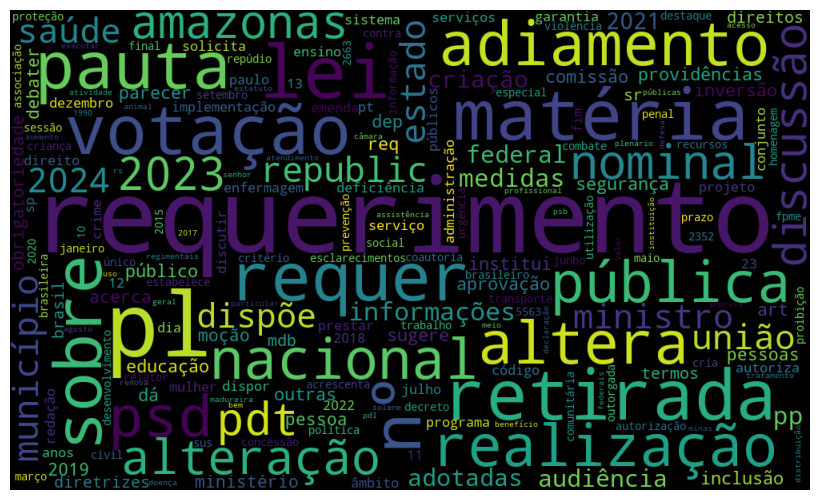

In [285]:
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)
y = le.fit_transform(df["sigla_partido"])
X_train, X_test, y_train, y_test = train_test_split(X, y)
model.fit(X_train, y_train)
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## PCA

In [286]:
le = LabelEncoder()

df["sigla_partido"] = le.fit_transform(df["sigla_partido"])
y = df["sigla_partido"]

In [287]:
y

0       14
1       24
2       24
3       19
4       14
        ..
5287    32
5288     8
5289    11
5290     6
5291    29
Name: sigla_partido, Length: 5292, dtype: int32

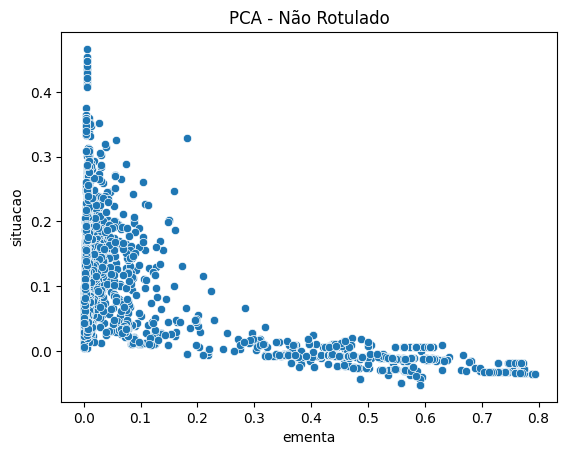

In [288]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["sigla_partido"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

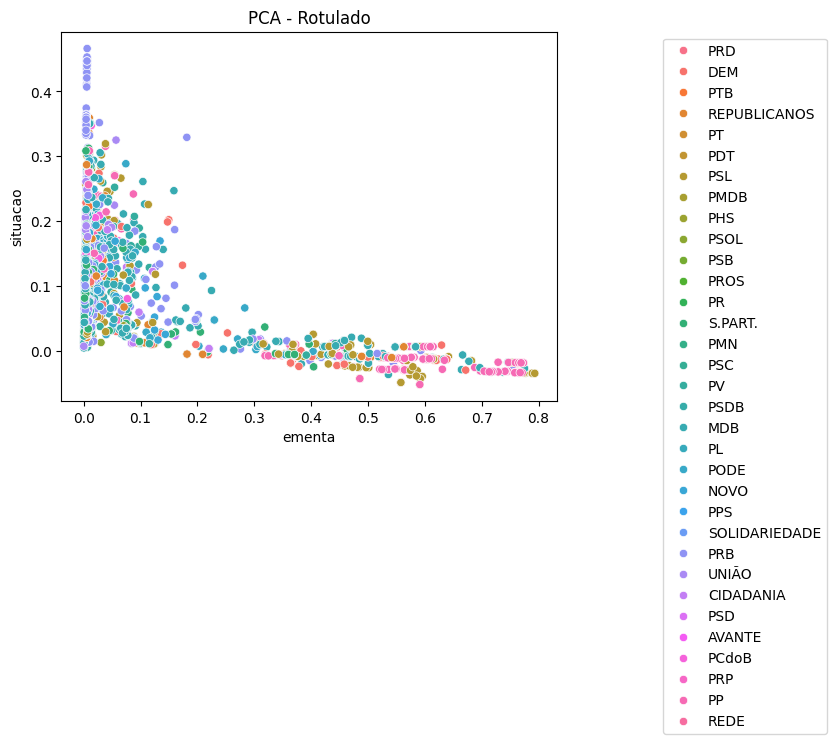

In [289]:
y_map = [partido[partido.index == i ].sigla_partido[i] for i in range(len(partido))]
number = [ i for i in range(len(y_map))]

y_map = dict(zip(number,y_map))


df_pca["target"] = df["sigla_partido"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca,)
plt.title('PCA - Rotulado')
plt.legend(bbox_to_anchor= (1.2,1))
plt.show()

In [290]:
df_pca

,ementa,situacao,target
0,0.003313,0.089476,PRD
1,0.001355,0.048333,DEM
2,0.003272,0.131292,DEM
3,0.004010,0.149782,PTB
4,0.026799,0.094424,PRD
...,...,...,...
5287,0.002615,0.099983,PRB
5288,0.091328,0.085797,MDB
5289,0.097177,0.059281,CIDADANIA
5290,0.024470,0.093061,NOVO


## Treino do Modelo

In [291]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [293]:
# from imblearn.over_sampling import SMOTE

# # transform the dataset
# oversample = SMOTE()
# X_train, y_train = oversample.fit_resample(X_train, y_train)

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 4, n_samples = 4

In [294]:
## Funçao para Avaliação dos Modelos
y_map = [partido[partido.index == i ].sigla_partido[i] for i in range(len(partido))]
def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=y_map)
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [295]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42) 

# Logistic Regression

In [296]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.16475994 0.21309191 0.17238382 0.17462296 0.20445595]
Media da Accuracy:  0.40362452718707775
Media da MACRO F1:  0.1858629190556487
Desvio Padrão da MACRO F1:  0.019185814037753803


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.33      0.08      0.12        13
           1       0.86      0.27      0.41        22
           2       0.00      0.00      0.00         1
           3       0.27      0.12      0.17        49
           4       0.73      0.69      0.71        68
           5       0.00      0.00      0.00        10
           6       0.76      0.30      0.43        44
           7       0.00      0.00      0.00         1
           8       0.38      0.72      0.50       262
           9       0.00      0.00      0.00         1
          11       0.50      0.09      0.15        23
          12       0.31      0.31      0.31        68
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00        15
          17       0.00      0.00      0.00  

c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

ValueError: The number of FixedLocator locations (29), usually from a call to set_ticks, does not match the number of labels (33).

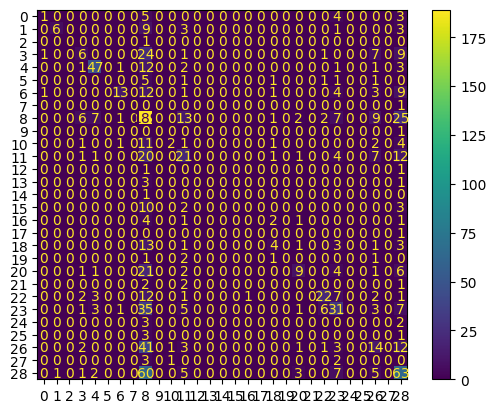

In [297]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [298]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py", line 917, in fit
    return self._fit(
           ^^^^^^^^^^
  File "c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\

In [299]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

# K Neighbors Classifier

In [300]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.18269765 0.26688055 0.20699836 0.18638577 0.19335408]
Media da Accuracy:  0.39984363034642306
Media da MACRO F1:  0.20726328255640963
Desvio Padrão da MACRO F1:  0.030942189657318826


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.45      0.38      0.42        13
           1       0.41      0.32      0.36        22
           2       0.00      0.00      0.00         1
           3       0.18      0.16      0.17        49
           4       0.77      0.75      0.76        68
           5       0.20      0.10      0.13        10
           6       0.41      0.30      0.34        44
           7       0.00      0.00      0.00         1
           8       0.51      0.54      0.52       262
           9       0.00      0.00      0.00         1
          11       0.18      0.13      0.15        23
          12       0.33      0.38      0.36        68
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         1
          16       0.10      0.07      0.08        15
          17       0.00      0.00      0.00  

c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

ValueError: The number of FixedLocator locations (30), usually from a call to set_ticks, does not match the number of labels (33).

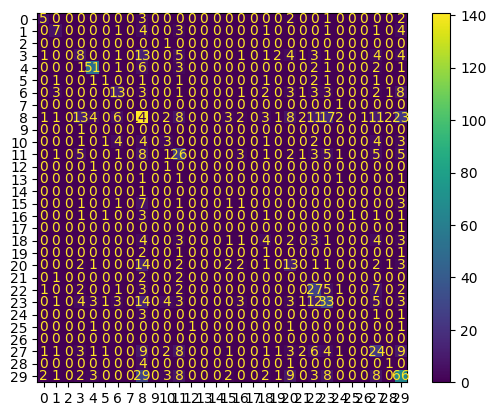

In [301]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [302]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.2031497  0.24693404 0.19455269 0.18359389 0.17948471]
Media da Accuracy:  0.38642993443541807
Media da MACRO F1:  0.20154300514033746
Desvio Padrão da MACRO F1:  0.024168288373032986


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.32      0.46      0.38        13
           1       0.33      0.41      0.37        22
           2       0.00      0.00      0.00         1
           3       0.19      0.20      0.20        49
           4       0.71      0.79      0.75        68
           5       0.07      0.10      0.08        10
           6       0.39      0.32      0.35        44
           7       1.00      1.00      1.00         1
           8       0.57      0.44      0.49       262
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0
          11       0.12      0.13      0.13        23
          12       0.29      0.35      0.32        68
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         1
          16       0.07      0.13      0.09  

c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

ValueError: The number of FixedLocator locations (31), usually from a call to set_ticks, does not match the number of labels (33).

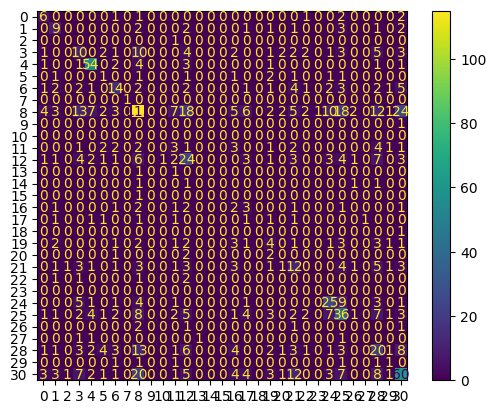

In [303]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [304]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.22873743 0.22694034 0.19174324 0.20232871 0.19106776]
Media da Accuracy:  0.4085333918827013
Media da MACRO F1:  0.2081634966572421
Desvio Padrão da MACRO F1:  0.016563755852897252


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.60      0.23      0.33        13
           1       0.88      0.32      0.47        22
           2       0.00      0.00      0.00         1
           3       0.33      0.12      0.18        49
           4       0.80      0.71      0.75        68
           5       0.25      0.10      0.14        10
           6       0.68      0.30      0.41        44
           7       1.00      1.00      1.00         1
           8       0.34      0.87      0.49       262
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0
          11       0.60      0.13      0.21        23
          12       0.53      0.28      0.37        68
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         1
          16       0.33      0.07      0.11  

c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

ValueError: The number of FixedLocator locations (30), usually from a call to set_ticks, does not match the number of labels (33).

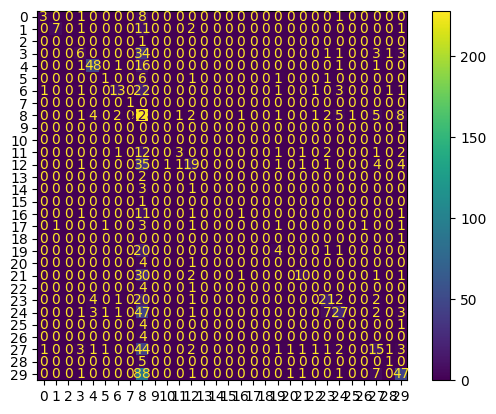

In [305]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [ ]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.63238648 0.6581477  0.64048673 0.62342989 0.5984154 ]
Media da Accuracy:  0.6689230769230768
Media da MACRO F1:  0.6305732389361395
Desvio Padrão da MACRO F1:  0.019733573025554698


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       730
           1       0.48      0.44      0.46       329

    accuracy                           0.68      1059
   macro avg       0.62      0.61      0.62      1059
weighted avg       0.67      0.68      0.68      1059



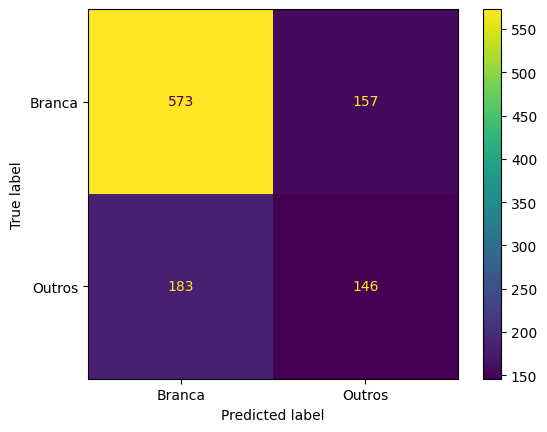

In [ ]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)